# Reconstruct the Stanford Bunny

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from tqdm.notebook import trange
import k3d
import sys
import os
import time
import copy
import trimesh
import mesh_to_sdf
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from models.model_architecture import PlaceholderNet, GeneralNet
from training.optimizers import GaussNewton, GaussNewtonNew
from util.surface_sampling import sample_model_surface_binsearch, sample_model_surface_newton 
from util.error_metrics import chamfer_div, compute_distance 
from util.visualization.utils_mesh import get_mesh

torch.manual_seed(0)


device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [2]:
mesh = trimesh.load("bun_zipper.ply")
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(mesh.vertices, mesh.faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(pts_sub.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()

/cluster/home/jaking/.local/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(
/cluster/home/jaking/.local/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int64" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

In [3]:
pts = torch.tensor(mesh.vertices, dtype=torch.float64)
true_normals = torch.tensor(mesh.vertex_normals, dtype=torch.float64)

center = pts.mean(dim=0)
pts -= center

scale = pts.norm(dim=1).max()
pts /= scale

subsample_fraction = 0.2
num_points = pts.shape[0]

# Randomly shuffle the points
indices = torch.randperm(num_points)
num_subsampled = int(subsample_fraction * num_points)
subsampled_indices = indices[:num_subsampled]
pts_sub = pts[subsampled_indices]
true_normals_sub = true_normals[subsampled_indices]


## Pretraining

In [4]:
model = PlaceholderNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
model = model.double()

# Generate random training points
num_pretrain_samples = 10000
bounds = torch.tensor([[-1.5, 1.5], [-1.5, 1.5], [-1.5, 1.5]], dtype=torch.float64)
pts_pretrain = torch.rand(num_pretrain_samples, 3, dtype=torch.float64) * (bounds[:,1] - bounds[:,0]) + bounds[:,0]

# SDF of a unit ball
def pretrain_loss(model, params, pts):
    inputs = pts.to(dtype=torch.float64)
    targets = inputs.norm(dim=1) - 1  # SDF of unit ball
    preds = model(inputs).squeeze(1)
    return 0.5 * (preds - targets).square().mean()

# Pretraining loop
pretrain_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_pretrain_iters = 1000

for i in range(num_pretrain_iters):
    pretrain_optimizer.zero_grad()
    loss = pretrain_loss(model, model.params, pts_pretrain)
    loss.backward()
    pretrain_optimizer.step()
    
    if i % 100 == 0:
        print(f"Pretrain Iter {i}: Loss = {loss.item():.6f}")

print("Pretraining completed!")


Pretrain Iter 0: Loss = 0.188104
Pretrain Iter 100: Loss = 0.087389
Pretrain Iter 200: Loss = 0.074126
Pretrain Iter 300: Loss = 0.001562
Pretrain Iter 400: Loss = 0.000543
Pretrain Iter 500: Loss = 0.000355
Pretrain Iter 600: Loss = 0.000285
Pretrain Iter 700: Loss = 0.000262
Pretrain Iter 800: Loss = 0.000259
Pretrain Iter 900: Loss = 0.000257
Pretraining completed!


In [5]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

/cluster/home/jaking/.local/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [6]:
# Loss weights:
# loss_weights = {"interface": 1.0, "eikonal": 0.01, "normal": 1.0}
loss_weights = {"interface": 1.0, "eikonal": 0.1, "normal": 1.0}



# pts_eikonal = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
min_vals = pts.min(dim=0).values-0.2  # min along each axis (x, y, z)
max_vals = pts.max(dim=0).values+0.2
# pts_eikonal = torch.rand([15000, 3], dtype=torch.float64)
pts_eikonal = torch.rand([4000, 3], dtype=torch.float64)
pts_eikonal = pts_eikonal * (max_vals - min_vals) + min_vals
# n_per_dim = int(round(4000 ** (1/3)))  # ~16 to get ~4096 points total

# x = torch.linspace(min_vals[0], max_vals[0], steps=n_per_dim, dtype=torch.float64)
# y = torch.linspace(min_vals[1], max_vals[1], steps=n_per_dim, dtype=torch.float64)
# z = torch.linspace(min_vals[2], max_vals[2], steps=n_per_dim, dtype=torch.float64)

# X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')
# pts_eikonal = torch.stack([X, Y, Z], dim=-1).reshape(-1, 3)

# pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
# pts_surface = pts

config = {
    "pts_boundary": pts_sub,
    "pts_eikonal": pts_eikonal,
    "pts_surface": pts_sub,
    "true_normals": true_normals_sub,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
    # "regularization": 1e-8,
    
}

# model = PlaceholderNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
# model.double()

  0%|          | 0/1000 [00:00<?, ?it/s]

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/torch/utils/_device.py:78: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3675.)
  return func(*args, **kwargs)


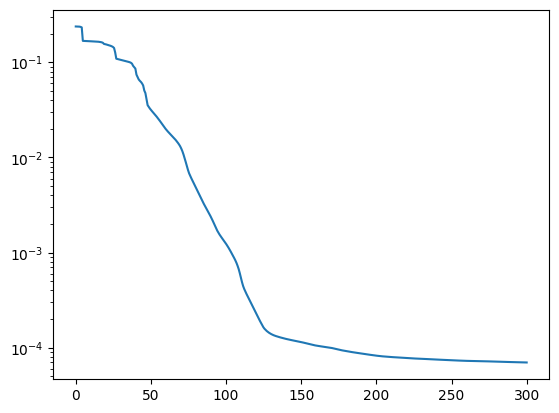

In [8]:
model = model.double()
params = model.params
loss_over_iters = {}
loss_over_time = {}
distance_over_time = {}
chamfer_over_time = {}
best_loss = float('inf')

# Gauss-Newton:
optimizer = GaussNewtonNew(model, lr=1e-1, config=config)

start_time = time.time()
current_time = 0

# Gauss-Newton:
optimizer = GaussNewtonNew(model, lr=1e-1, config=config)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(1000)):
    if current_time > 300:
        break
    optimizer.zero_grad()
    with torch.no_grad():
        loss_interface  = 0.5*model.f(params, pts_sub).square().mean()
        loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()
        loss_normal = 0.5*model.r_normal(params, pts_sub, true_normals_sub).squeeze(1).square().mean()
        # loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["normal"] * loss_normal
        loss_metric = loss_interface + loss_normal
        loss_over_time[current_time] = loss_metric.item()
        pbar.set_description(f"Interface: {loss_interface.item():.2e} "
                             f"Eikonal: {loss_eikonal.item():.2e} "
                             f"Normal: {loss_normal.item():.2e} "
                             f"{len(pts_sub)}")
        if loss_metric.item() < best_loss:
            best_loss = loss_metric.item()
            best_model_state = copy.deepcopy(model.state_dict())
    optimizer.step()
    current_time = time.time() - start_time

plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

  0%|          | 0/100000 [00:00<?, ?it/s]

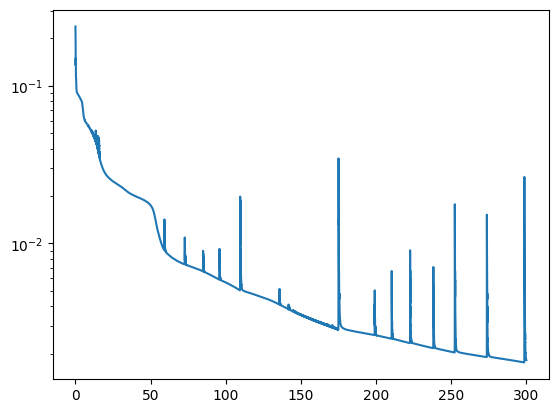

In [7]:
model = model.double()
params = model.params
loss_over_iters = {}
loss_over_time = {}
distance_over_time = {}
chamfer_over_time = {}
best_loss = float('inf')

start_time = time.time()
current_time = 0

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=18000)

for i in (pbar:=trange(100000)):
    if current_time > 300:
        break
    optimizer.zero_grad()
    loss_interface  = 0.5*model.f(params, pts_sub).square().mean()
    loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()
    loss_normal = 0.5*model.r_normal(params, pts_sub, true_normals_sub).squeeze(1).square().mean()
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["normal"] * loss_normal
    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_normal
        loss_over_time[current_time] = loss_metric.item()
        pbar.set_description(f"Interface: {loss_interface.item():.2e} "
                             f"Eikonal: {loss_eikonal.item():.2e} "
                             f"Normal: {loss_normal.item():.2e} "
                             f"{len(pts_sub)}")
        if loss_metric.item() < best_loss:
            best_loss = loss_metric.item()
            best_model_state = copy.deepcopy(model.state_dict())
    optimizer.step()
    current_time = time.time() - start_time

plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

In [20]:
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewton(model, lr=1e-2, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(1000)):
    optimizer.zero_grad()

    loss_interface  = 0.5*model.f(params, pts_surface_original).square().mean()
    loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()

    # pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
    pts_surface = sample_model_surface_newton(model, pts_eikonal) 
    config["pts_surface"] = pts_surface
    optimizer.config = config
    loss_mean_curvature = 0.5*model.r_mean_curvature(params, pts_surface).squeeze(1).square().mean()
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["mean_curvature"] * loss_mean_curvature
    loss.backward()
    with torch.no_grad():
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Interface: {loss_interface.item():.2e} "
                             f"Eikonal: {loss_eikonal.item():.2e} "
                             f"Mean Curvature: {loss_mean_curvature.item():.2e} "
                             f"{len(pts_surface)}")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

NameError: name 'pts_surface_original' is not defined

In [8]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=pts.min(dim=0).values-0.01,
    bbox_max=pts.max(dim=0).values+0.15,
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [9]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=pts.min(dim=0).values-0.01,
    bbox_max=pts.max(dim=0).values+0.15,
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [9]:
torch.save(model.state_dict(), '3,32,32,32,1,sin,bunny,adam')

In [9]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=pts.min(dim=0).values-0.01,
    bbox_max=pts.max(dim=0).values+0.15,
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [18]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=pts.min(dim=0).values-0.01,
    bbox_max=pts.max(dim=0).values+0.15,
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)